In [1]:
# Install LeRobot
!pip install -q lerobot

print("LeRobot installation complete!")

LeRobot installation complete!


In [2]:
import lerobot

print("LeRobot version:", getattr(lerobot, "__version__", "version not exposed"))
print("LeRobot location:", lerobot.__file__)

LeRobot version: 0.6.1
LeRobot location: /usr/local/lib/python3.13/dist-packages/lerobot/__init__.py


In [4]:
#Check the hugging face dataset

from huggingface_hub import list_repo_files

dataset_id = "lerobot/svla_so100_pickplace"

files = list_repo_files(dataset_id, repo_type="dataset")

print(f"Dataset: {dataset_id}")
print(f"Number of files: {len(files)}")
print("\nFirst 30 files:")
for f in files[:30]:
    print(f)

Dataset: lerobot/svla_so100_pickplace
Number of files: 9

First 30 files:
.gitattributes
README.md
data/chunk-000/file-000.parquet
meta/episodes/chunk-000/file-000.parquet
meta/info.json
meta/stats.json
meta/tasks.parquet
videos/observation.images.top/chunk-000/file-000.mp4
videos/observation.images.wrist/chunk-000/file-000.mp4


In [5]:
#Inspect the meta data

from huggingface_hub import hf_hub_download
import pandas as pd
import json

dataset_id = "lerobot/svla_so100_pickplace"

# Download only the small metadata files
info_path = hf_hub_download(
    repo_id=dataset_id,
    filename="meta/info.json",
    repo_type="dataset"
)

tasks_path = hf_hub_download(
    repo_id=dataset_id,
    filename="meta/tasks.parquet",
    repo_type="dataset"
)

episodes_path = hf_hub_download(
    repo_id=dataset_id,
    filename="meta/episodes/chunk-000/file-000.parquet",
    repo_type="dataset"
)

# Read metadata
with open(info_path, "r") as f:
    info = json.load(f)

tasks = pd.read_parquet(tasks_path)
episodes = pd.read_parquet(episodes_path)

print("=== DATASET INFO ===")
print(json.dumps(info, indent=2))

print("\n=== TASKS ===")
display(tasks.head(10))

print("\n=== EPISODES ===")
display(episodes.head(10))

print("\nNumber of episodes:", len(episodes))
print("Number of tasks:", len(tasks))

=== DATASET INFO ===
{
  "codebase_version": "v3.0",
  "robot_type": "so100",
  "total_episodes": 50,
  "total_frames": 19631,
  "total_tasks": 1,
  "chunks_size": 1000,
  "fps": 30,
  "splits": {
    "train": "0:50"
  },
  "data_path": "data/chunk-{chunk_index:03d}/file-{file_index:03d}.parquet",
  "video_path": "videos/{video_key}/chunk-{chunk_index:03d}/file-{file_index:03d}.mp4",
  "features": {
    "action": {
      "dtype": "float32",
      "shape": [
        6
      ],
      "names": [
        "main_shoulder_pan",
        "main_shoulder_lift",
        "main_elbow_flex",
        "main_wrist_flex",
        "main_wrist_roll",
        "main_gripper"
      ],
      "fps": 30.0
    },
    "observation.state": {
      "dtype": "float32",
      "shape": [
        6
      ],
      "names": [
        "main_shoulder_pan",
        "main_shoulder_lift",
        "main_elbow_flex",
        "main_wrist_flex",
        "main_wrist_roll",
        "main_gripper"
      ],
      "fps": 30.0
    },
  

,task_index
Pick up the cube and place it in the box.,0



=== EPISODES ===


,episode_index,data/chunk_index,data/file_index,dataset_from_index,dataset_to_index,videos/observation.images.top/chunk_index,videos/observation.images.top/file_index,videos/observation.images.top/from_timestamp,videos/observation.images.top/to_timestamp,videos/observation.images.wrist/chunk_index,...,stats/index/mean,stats/index/std,stats/index/count,stats/task_index/min,stats/task_index/max,stats/task_index/mean,stats/task_index/std,stats/task_index/count,meta/episodes/chunk_index,meta/episodes/file_index
0,0,0,0,0,454,0,0,0.000000,15.133333,0,...,[226.5],[131.0581931815024],[454],[0],[0],[0.0],[0.0],[454],0,0
1,1,0,0,454,922,0,0,15.133333,30.733333,0,...,[687.5],[135.09965457641508],[468],[0],[0],[0.0],[0.0],[468],0,0
2,2,0,0,922,1342,0,0,30.733333,44.733333,0,...,[1131.5],[121.24321286845984],[420],[0],[0],[0.0],[0.0],[420],0,0
3,3,0,0,1342,1758,0,0,44.733333,58.600000,0,...,[1549.5],[120.08850902563492],[416],[0],[0],[0.0],[0.0],[416],0,0
4,4,0,0,1758,2159,0,0,58.600000,71.966667,0,...,[1958.0],[115.75836902790225],[401],[0],[0],[0.0],[0.0],[401],0,0
5,5,0,0,2159,2513,0,0,71.966667,83.766667,0,...,[2335.5],[102.1905899125094],[354],[0],[0],[0.0],[0.0],[354],0,0
6,6,0,0,2513,2870,0,0,83.766667,95.666667,0,...,[2691.0],[103.05661874264392],[357],[0],[0],[0.0],[0.0],[357],0,0
7,7,0,0,2870,3221,0,0,95.666667,107.366667,0,...,[3045.0],[101.32456102380442],[351],[0],[0],[0.0],[0.0],[351],0,0
8,8,0,0,3221,3589,0,0,107.366667,119.633334,0,...,[3404.5],[106.23205730851681],[368],[0],[0],[0.0],[0.0],[368],0,0
9,9,0,0,3589,3977,0,0,119.633334,132.566667,0,...,[3782.5],[112.0055802181302],[388],[0],[0],[0.0],[0.0],[388],0,0



Number of episodes: 50
Number of tasks: 1


In [6]:
#Download episode 0's videos

from huggingface_hub import hf_hub_download

dataset_id = "lerobot/svla_so100_pickplace"

top_video = hf_hub_download(
    repo_id=dataset_id,
    filename="videos/observation.images.top/chunk-000/file-000.mp4",
    repo_type="dataset"
)

wrist_video = hf_hub_download(
    repo_id=dataset_id,
    filename="videos/observation.images.wrist/chunk-000/file-000.mp4",
    repo_type="dataset"
)

print("Top camera:", top_video)
print("Wrist camera:", wrist_video)

Top camera: /root/.cache/huggingface/hub/datasets--lerobot--svla_so100_pickplace/snapshots/728583b5eaf9e739a7f119e2def466fa1d552402/videos/observation.images.top/chunk-000/file-000.mp4
Wrist camera: /root/.cache/huggingface/hub/datasets--lerobot--svla_so100_pickplace/snapshots/728583b5eaf9e739a7f119e2def466fa1d552402/videos/observation.images.wrist/chunk-000/file-000.mp4


Episode 0:
  Start frame: 0
  End frame:   454
  Frames:      454
  Duration:    15.13 seconds


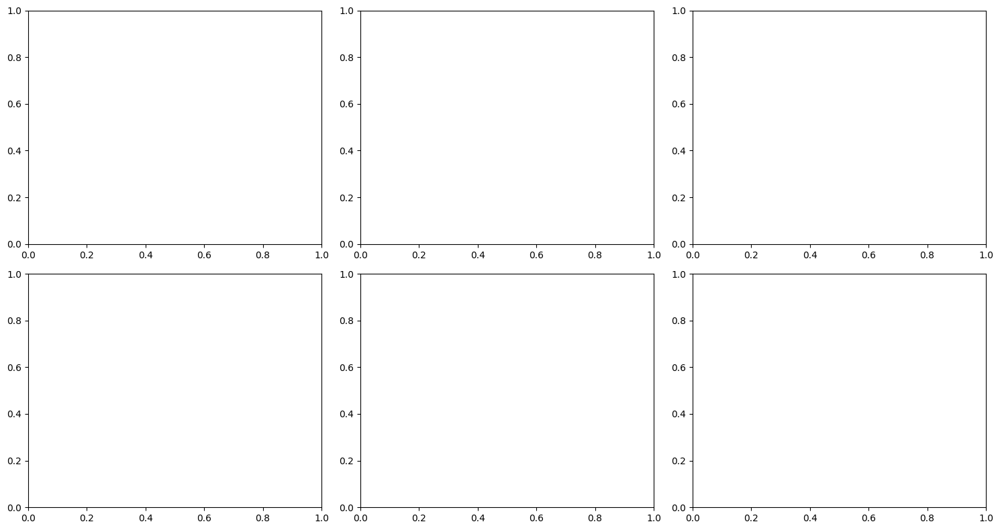

In [7]:
#Extract frames from episode 0
import cv2
import os
import matplotlib.pyplot as plt

# Episode 0 information from our metadata
episode = episodes.iloc[0]

start_frame = int(episode["dataset_from_index"])
end_frame = int(episode["dataset_to_index"])

print(f"Episode 0:")
print(f"  Start frame: {start_frame}")
print(f"  End frame:   {end_frame}")
print(f"  Frames:      {end_frame - start_frame}")
print(f"  Duration:    {(end_frame - start_frame) / 30:.2f} seconds")

# Open the top-camera video
cap = cv2.VideoCapture(top_video)

# Extract 6 evenly-spaced frames from episode 0
frame_numbers = [
    int(start_frame + i * (end_frame - start_frame) / 5)
    for i in range(6)
]

frames = []

for frame_number in frame_numbers:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    success, frame = cap.read()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((frame_number, frame))

cap.release()

# Display frames
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (frame_number, frame) in zip(axes.flat, frames):
    ax.imshow(frame)
    ax.set_title(f"Frame {frame_number}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
#Inspect the actions for episode 0

# Download the actual robot data
data_path = hf_hub_download(
    repo_id=dataset_id,
    filename="data/chunk-000/file-000.parquet",
    repo_type="dataset"
)

# Load the robot data
data = pd.read_parquet(data_path)

# Get only episode 0
episode_0_data = data[
    data["episode_index"] == 0
].copy()

print("Episode 0 shape:", episode_0_data.shape)

# Show the useful columns
display(
    episode_0_data[
        [
            "timestamp",
            "frame_index",
            "action",
            "observation.state"
        ]
    ].head(10)
)

Episode 0 shape: (454, 7)


,timestamp,frame_index,action,observation.state
0,0.000000,0,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
1,0.033333,1,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
2,0.066667,2,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
3,0.100000,3,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
4,0.133333,4,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
5,0.166667,5,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
6,0.200000,6,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
7,0.233333,7,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
8,0.266667,8,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."
9,0.300000,9,"[0.6152344, -87.1875, 74.61914, 72.333984, 82....","[0.3515625, -86.83594, 75.05859, 72.07031, 82...."


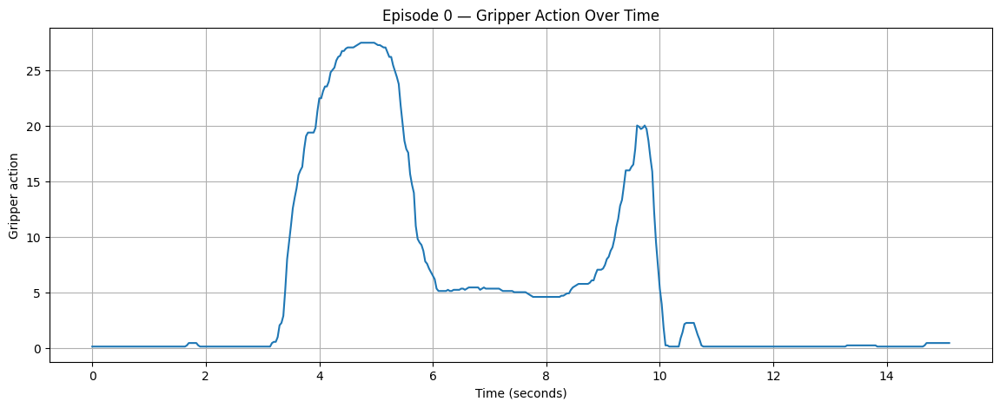

Gripper minimum: 0.106496274
Gripper maximum: 27.47604


In [9]:
#Plot the gripper action
import numpy as np
import matplotlib.pyplot as plt

# Extract the 6-dimensional action vectors
actions = np.stack(episode_0_data["action"].values)

# According to the dataset metadata, gripper is dimension 5
gripper = actions[:, 5]

timestamps = episode_0_data["timestamp"].values

plt.figure(figsize=(14, 5))
plt.plot(timestamps, gripper)
plt.xlabel("Time (seconds)")
plt.ylabel("Gripper action")
plt.title("Episode 0 — Gripper Action Over Time")
plt.grid(True)
plt.show()

print("Gripper minimum:", gripper.min())
print("Gripper maximum:", gripper.max())

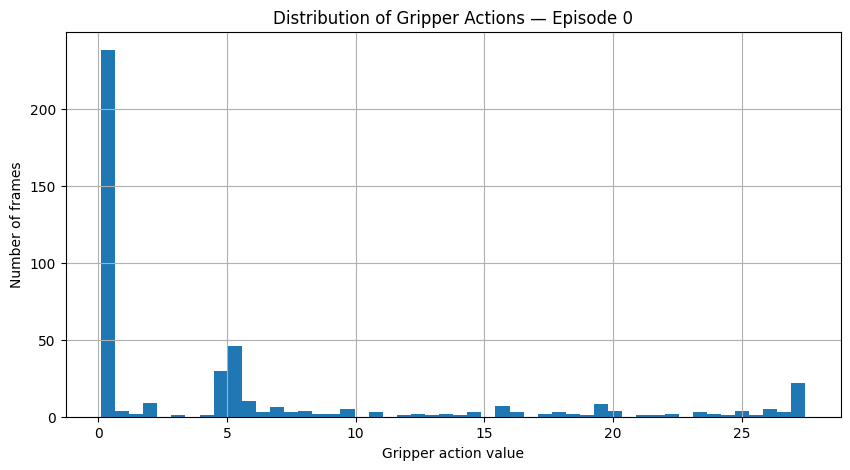

In [10]:
# visualize the gripper signal with its distribution

plt.figure(figsize=(10, 5))

plt.hist(gripper, bins=50)

plt.xlabel("Gripper action value")
plt.ylabel("Number of frames")
plt.title("Distribution of Gripper Actions — Episode 0")
plt.grid(True)

plt.show()

In [11]:
# Show gripper values at regular intervals
sample_indices = np.linspace(0, len(gripper) - 1, 20).astype(int)

gripper_samples = pd.DataFrame({
    "frame": episode_0_data.iloc[sample_indices]["frame_index"].values,
    "time_sec": episode_0_data.iloc[sample_indices]["timestamp"].values,
    "gripper": gripper[sample_indices]
})

display(gripper_samples)

,frame,time_sec,gripper
0,0,0.000000,0.106496
1,23,0.766667,0.106496
2,47,1.566667,0.106496
3,71,2.366667,0.106496
4,95,3.166667,0.425985
5,119,3.966667,21.299255
6,143,4.766667,27.476040
7,166,5.533333,17.891375
8,190,6.333333,5.111821
9,214,7.133333,5.324814


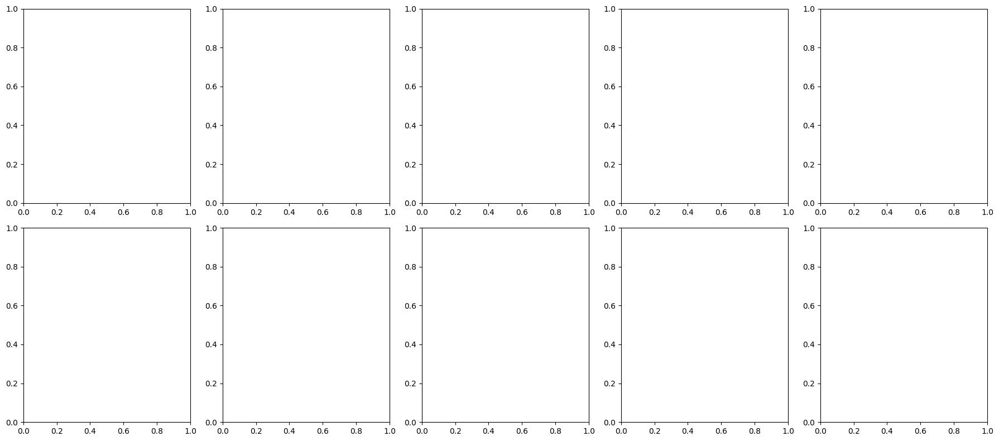

In [12]:
# Inspect the critical moments

# Frames around the major gripper changes
interesting_times = [
    2.5,
    3.5,
    4.0,
    4.5,
    5.0,
    6.0,
    8.5,
    9.0,
    9.5,
    10.0
]

cap = cv2.VideoCapture(top_video)

frames = []

for t in interesting_times:
    frame_number = int(start_frame + t * 30)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    success, frame = cap.read()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((t, frame))

cap.release()

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, (t, frame) in zip(axes.flat, frames):
    ax.imshow(frame)
    ax.set_title(f"{t:.1f} seconds")
    ax.axis("off")

plt.tight_layout()
plt.show()

Successfully decoded: 10 of 10 frames


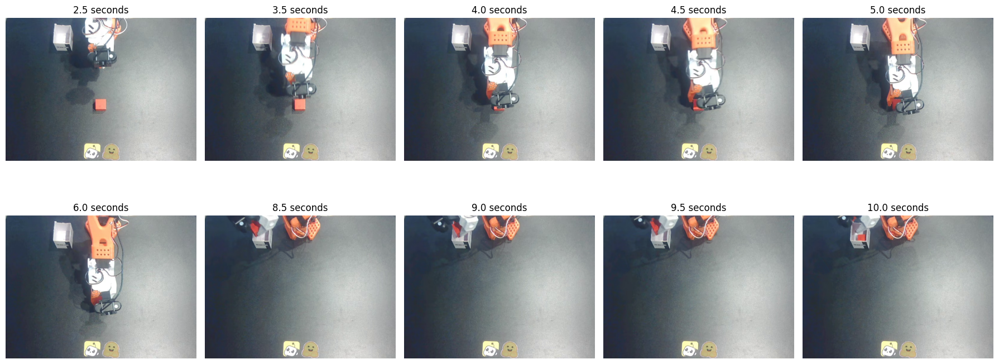

In [13]:
# Install PyAV, which has better video codec support
!pip install -q av

import av
import numpy as np
import matplotlib.pyplot as plt

interesting_times = [
    2.5, 3.5, 4.0, 4.5, 5.0,
    6.0, 8.5, 9.0, 9.5, 10.0
]

target_frames = [int(t * 30) for t in interesting_times]

container = av.open(top_video)

frames = {}

for i, frame in enumerate(container.decode(video=0)):
    if i in target_frames:
        frames[i] = frame.to_ndarray(format="rgb24")

    # We only need the first ~10 seconds
    if i > max(target_frames):
        break

container.close()

print("Successfully decoded:", len(frames), "of", len(target_frames), "frames")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, t, frame_number in zip(
    axes.flat,
    interesting_times,
    target_frames
):
    if frame_number in frames:
        ax.imshow(frames[frame_number])
        ax.set_title(f"{t:.1f} seconds")
    else:
        ax.set_title(f"{t:.1f} seconds — missing")

    ax.axis("off")

plt.tight_layout()
plt.show()

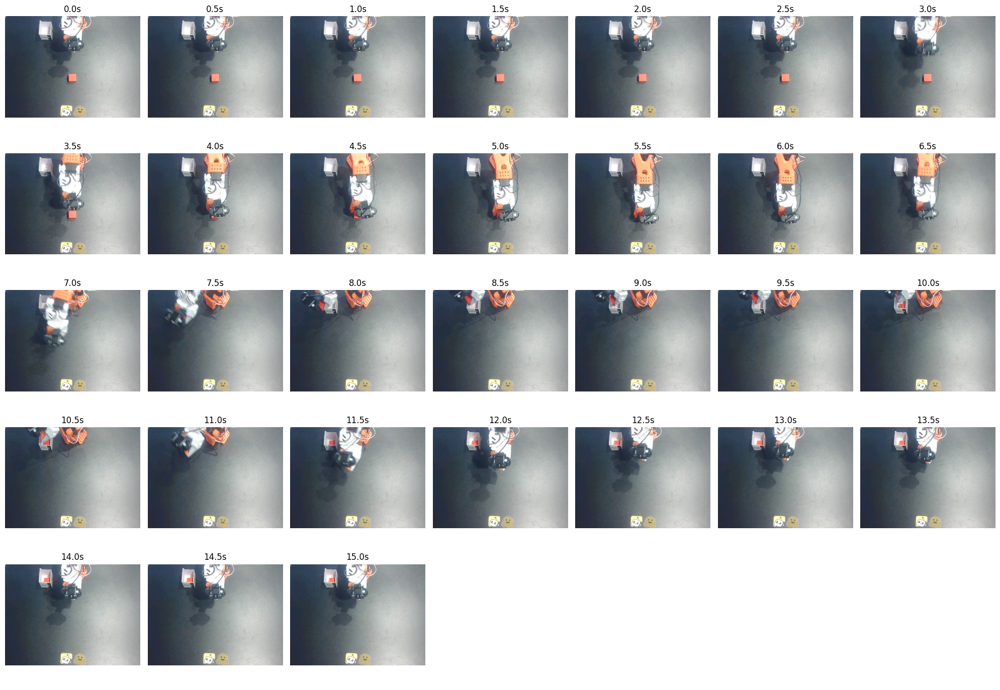

In [14]:
# Create a visual timeline for Episode 0
# One frame every 0.5 seconds

import av
import matplotlib.pyplot as plt

times = np.arange(0, 15.1, 0.5)
target_frames = [int(t * 30) for t in times]

container = av.open(top_video)

frames = {}

for i, frame in enumerate(container.decode(video=0)):
    if i in target_frames:
        frames[i] = frame.to_ndarray(format="rgb24")

    if i > max(target_frames):
        break

container.close()

fig, axes = plt.subplots(5, 7, figsize=(20, 14))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, t, frame_number in zip(axes, times, target_frames):
    if frame_number in frames:
        ax.imshow(frames[frame_number])
        ax.set_title(f"{t:.1f}s")

    ax.axis("off")

plt.tight_layout()
plt.show()

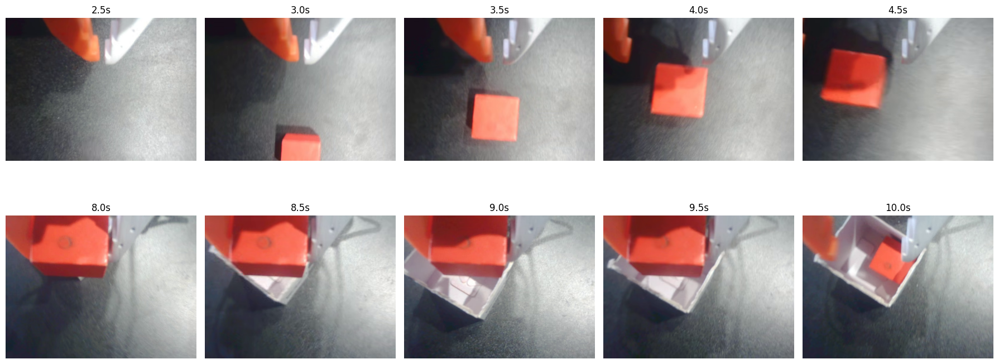

In [15]:
# Inspect the wrist camera around the likely grasp and release moments

import av
import numpy as np
import matplotlib.pyplot as plt

times = [
    2.5, 3.0, 3.5, 4.0, 4.5,
    8.0, 8.5, 9.0, 9.5, 10.0
]

target_frames = [int(t * 30) for t in times]

container = av.open(wrist_video)

frames = {}

for i, frame in enumerate(container.decode(video=0)):
    if i in target_frames:
        frames[i] = frame.to_ndarray(format="rgb24")

    if i > max(target_frames):
        break

container.close()

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, t, frame_number in zip(axes.flat, times, target_frames):
    if frame_number in frames:
        ax.imshow(frames[frame_number])
        ax.set_title(f"{t:.1f}s")
    else:
        ax.set_title(f"{t:.1f}s — missing")

    ax.axis("off")

plt.tight_layout()
plt.show()

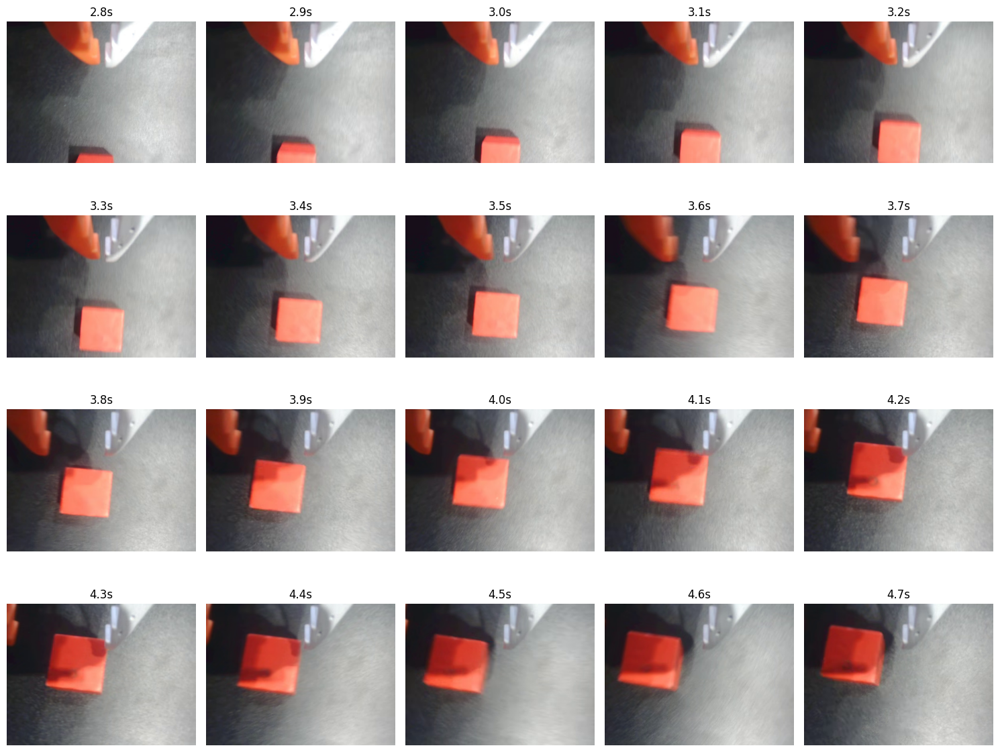

In [16]:
# Inspect the grasp transition in detail

times = np.arange(2.8, 4.7, 0.1)
target_frames = [int(t * 30) for t in times]

container = av.open(wrist_video)

frames = {}

for i, frame in enumerate(container.decode(video=0)):
    if i in target_frames:
        frames[i] = frame.to_ndarray(format="rgb24")

    if i > max(target_frames):
        break

container.close()

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, t, frame_number in zip(axes, times, target_frames):
    if frame_number in frames:
        ax.imshow(frames[frame_number])
        ax.set_title(f"{t:.1f}s")
    ax.axis("off")

plt.tight_layout()
plt.show()

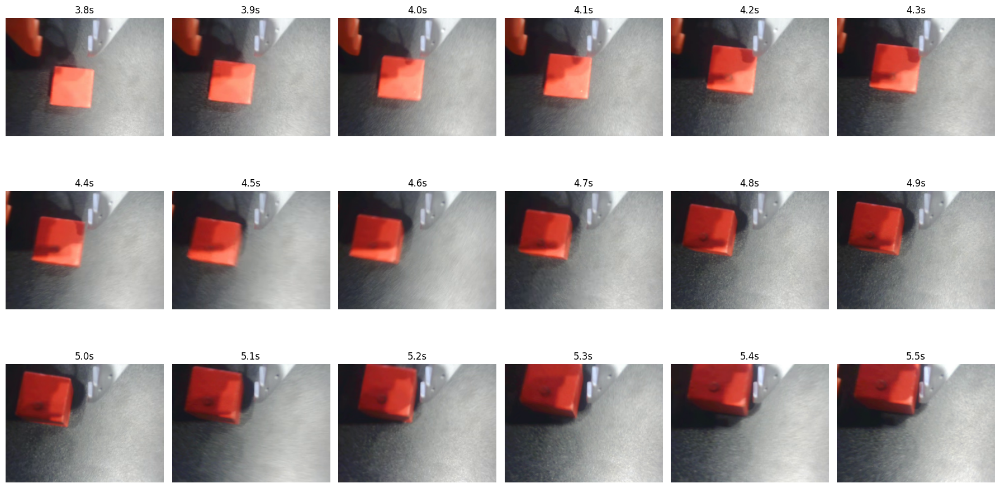

In [17]:
# Inspect the likely grasp interval

times = np.arange(3.8, 5.6, 0.1)
target_frames = [int(t * 30) for t in times]

container = av.open(wrist_video)

frames = {}

for i, frame in enumerate(container.decode(video=0)):
    if i in target_frames:
        frames[i] = frame.to_ndarray(format="rgb24")

    if i > max(target_frames):
        break

container.close()

fig, axes = plt.subplots(3, 6, figsize=(18, 10))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, t, frame_number in zip(axes, times, target_frames):
    if frame_number in frames:
        ax.imshow(frames[frame_number])
        ax.set_title(f"{t:.1f}s")

plt.tight_layout()
plt.show()

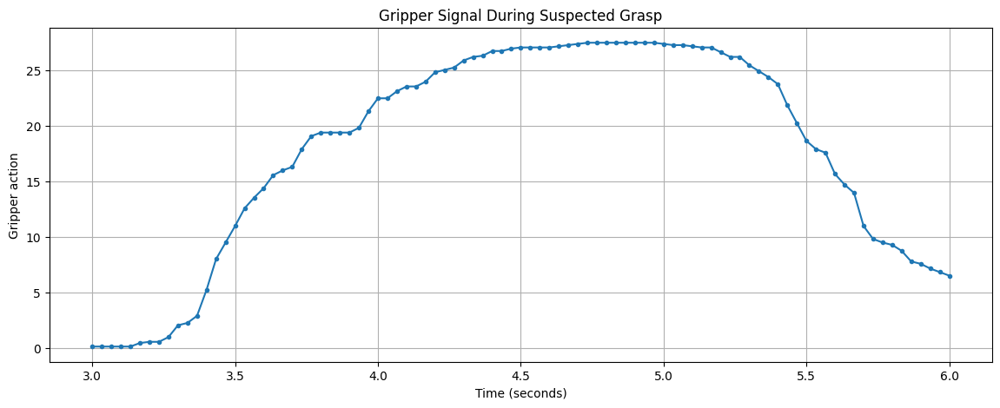

,time,frame,gripper
0,3.0,90,0.106496
1,3.2,96,0.532481
2,3.4,102,5.218318
3,3.6,108,14.376996
4,3.8,114,19.382322
5,4.0,120,22.470715
6,4.2,126,24.813631
7,4.4,132,26.730564
8,4.6,138,27.050055
9,4.8,144,27.476040


In [18]:
# Inspect gripper telemetry around the suspected grasp

mask = (
    (episode_0_data["timestamp"] >= 3.0) &
    (episode_0_data["timestamp"] <= 6.0)
)

grasp_window = episode_0_data[mask].copy()

actions = np.stack(grasp_window["action"].values)
gripper_window = actions[:, 5]

plt.figure(figsize=(14, 5))

plt.plot(
    grasp_window["timestamp"],
    gripper_window,
    marker="."
)

plt.xlabel("Time (seconds)")
plt.ylabel("Gripper action")
plt.title("Gripper Signal During Suspected Grasp")
plt.grid(True)

plt.show()

# Print values every 0.2 seconds
sample_times = np.arange(3.0, 6.01, 0.2)

rows = []

for t in sample_times:
    idx = np.abs(
        grasp_window["timestamp"].values - t
    ).argmin()

    rows.append({
        "time": grasp_window.iloc[idx]["timestamp"],
        "frame": grasp_window.iloc[idx]["frame_index"],
        "gripper": gripper_window[idx]
    })

display(pd.DataFrame(rows))

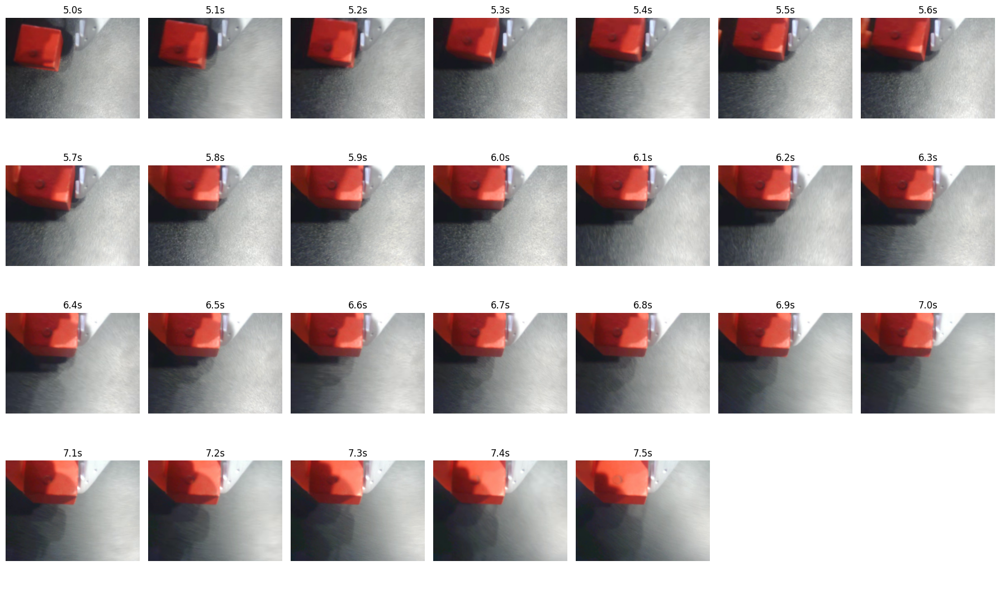

In [19]:
# Inspect the transition from grasping to carrying/transport

times = np.arange(5.0, 7.6, 0.1)
target_frames = [int(t * 30) for t in times]

container = av.open(wrist_video)

frames = {}

for i, frame in enumerate(container.decode(video=0)):
    if i in target_frames:
        frames[i] = frame.to_ndarray(format="rgb24")

    if i > max(target_frames):
        break

container.close()

fig, axes = plt.subplots(4, 7, figsize=(18, 11))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, t, frame_number in zip(axes, times, target_frames):
    if frame_number in frames:
        ax.imshow(frames[frame_number])
        ax.set_title(f"{t:.1f}s")

plt.tight_layout()
plt.show()

In [20]:
!pip install -q label-studio

print("Label Studio installed!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.
Label Studio installed!


In [21]:
# Fix dependency versions so LeRobot + Label Studio
# can coexist in this Colab environment.

!pip install -q \
    "numpy>=2.0,<2.3" \
    "setuptools>=71,<82" \
    "protobuf>=5.29,<6"

print("Dependencies fixed.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.83.1 requires protobuf<8.0.0,>=6.33.5, but you have protobuf 5.29.6 which is incompatible.
google-cloud-audit-log 0.6.2 requires protobuf<8.0.0,>=6.33.5, but you have protobuf 5.29.6 which is incompatible.
google-cloud-logging 3.16.3 requires protobuf<8.0.0,>=6.33.5, but you have protobuf 5.29.6 which is incompatible.
Dependencies fixed.


In [22]:
import numpy
import setuptools
import google.protobuf

print("NumPy:", numpy.__version__)
print("Setuptools:", setuptools.__version__)
print("Protobuf:", google.protobuf.__version__)

NumPy: 2.2.6
Setuptools: 81.0.0
Protobuf: 5.29.6


In [23]:
import label_studio

print("Label Studio imported successfully!")
print("Version:", getattr(label_studio, "__version__", "version not exposed"))

Label Studio imported successfully!
Version: 1.23.0


In [24]:
import subprocess
import time

# Start Label Studio in the background
process = subprocess.Popen(
    [
        "label-studio",
        "start",
        "--port", "8080",
        "--host", "0.0.0.0",
        "--no-browser"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Label Studio server started on port 8080")

Label Studio server started on port 8080


In [25]:
print("Label Studio should still be running on port 8080.")

Label Studio should still be running on port 8080.


In [26]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8080)")
print("Open Label Studio here:")
print(url)

Open Label Studio here:
https://8080-m-s-kkb-usw1c0-1ilfup7htjprs-c.us-west1-0.prod.colab.dev


In [27]:
import subprocess

# Check whether anything is listening on port 8080
result = subprocess.run(
    ["bash", "-c", "curl -s -o /dev/null -w '%{http_code}' http://127.0.0.1:8080"],
    capture_output=True,
    text=True
)

print("HTTP status from Label Studio:", result.stdout)

HTTP status from Label Studio: 404


In [28]:
import requests

urls = [
    "http://127.0.0.1:8080/",
    "http://127.0.0.1:8080/api/health",
    "http://127.0.0.1:8080/health",
]

for url in urls:
    try:
        r = requests.get(url, timeout=5)
        print(f"{url}")
        print(f"  Status: {r.status_code}")
        print(f"  Final URL: {r.url}")
        print()
    except Exception as e:
        print(f"{url} -> ERROR: {e}")

http://127.0.0.1:8080/
  Status: 404
  Final URL: http://127.0.0.1:8080/

http://127.0.0.1:8080/api/health
  Status: 404
  Final URL: http://127.0.0.1:8080/api/health

http://127.0.0.1:8080/health
  Status: 404
  Final URL: http://127.0.0.1:8080/health



In [29]:
import subprocess
import requests

print("=== Processes containing Label Studio ===")
result = subprocess.run(
    ["bash", "-c", "ps aux | grep -i '[l]abel-studio'"],
    capture_output=True,
    text=True
)
print(result.stdout or "No Label Studio process found.")

print("\n=== Process listening on port 8080 ===")
result = subprocess.run(
    ["bash", "-c", "lsof -i :8080 -P -n"],
    capture_output=True,
    text=True
)
print(result.stdout or "Nothing found on port 8080.")

print("\n=== Label Studio version endpoint ===")
try:
    r = requests.get("http://127.0.0.1:8080/api/version/", timeout=5)
    print("Status:", r.status_code)
    print("Response:", r.text[:1000])
except Exception as e:
    print("ERROR:", e)

=== Processes containing Label Studio ===
root       71805 12.4  3.6 960696 481392 ?       Sl   08:31   0:13 /usr/bin/python3 /usr/local/bin/label-studio start --port 8080 --host 0.0.0.0 --no-browser


=== Process listening on port 8080 ===
COMMAND   PID USER   FD   TYPE  DEVICE SIZE/OFF NODE NAME
node        7 root   19u  IPv6   19604      0t0  TCP *:8080 (LISTEN)
node        7 root   23u  IPv6 1731344      0t0  TCP 172.28.0.12:8080->172.28.0.1:38250 (ESTABLISHED)
node        7 root   25u  IPv6 1627147      0t0  TCP 172.28.0.12:8080->172.28.0.1:33000 (ESTABLISHED)
node        7 root   27u  IPv6 1745693      0t0  TCP 127.0.0.1:8080->127.0.0.1:47952 (ESTABLISHED)
python3 39133 root   59u  IPv4 1745692      0t0  TCP 127.0.0.1:47952->127.0.0.1:8080 (ESTABLISHED)


=== Label Studio version endpoint ===
Status: 404
Response: <!DOCTYPE HTML>
<html>

<head>

    <meta charset="utf-8">

    <title>Jupyter Server</title>
    <link id="favicon" rel="shortcut icon" type="image/x-icon" href="/stat

In [30]:
import subprocess

subprocess.run(
    ["bash", "-c", "pkill -f 'label-studio start'"],
    check=False
)

print("Old Label Studio process stopped.")

Old Label Studio process stopped.


In [31]:
import subprocess
import time

process = subprocess.Popen(
    [
        "label-studio",
        "start",
        "--port", "8081",
        "--host", "0.0.0.0",
        "--no-browser"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(8)

print("Label Studio started on port 8081.")

Label Studio started on port 8081.


In [32]:
import requests

response = requests.get("http://127.0.0.1:8081")

print("HTTP status:", response.status_code)
print("Server:", response.headers.get("Server"))
print("Response starts with:")
print(response.text[:200])

HTTP status: 200
Server: WSGIServer/0.2 CPython/3.13.15
Response starts with:



<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <meta name="author" content=""/>
  <meta name="viewport" content="width=device-width, initial-scale=0.9, shrink-to-fit=no">

  <!-


In [33]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8081)")
print("Open this URL in your browser:")
print(url)

Open this URL in your browser:
https://8081-m-s-kkb-usw1c0-1ilfup7htjprs-c.us-west1-0.prod.colab.dev


In [34]:
import subprocess
import time
import getpass

# Your Colab proxy URL
LABEL_STUDIO_URL = "https://8081-m-s-kkb-usw1c0-1ilfup7htjprs-c.us-west1-0.prod.colab.dev"

email = input("Enter email for this temporary Label Studio account: ")
password = getpass.getpass("Create a password (8+ characters): ")

# Stop the existing Label Studio process
subprocess.run(
    ["bash", "-c", "pkill -f 'label-studio start'"],
    check=False
)

time.sleep(2)

# Start Label Studio with the user created from the command line
env = {
    **__import__("os").environ,
    "LABEL_STUDIO_HOST": LABEL_STUDIO_URL,
    "CSRF_TRUSTED_ORIGINS": LABEL_STUDIO_URL,
}

process = subprocess.Popen(
    [
        "label-studio",
        "start",
        "--port", "8081",
        "--host", "0.0.0.0",
        "--no-browser",
        "--username", email,
        "--password", password,
    ],
    env=env,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

time.sleep(8)

print("Label Studio restarted with the account configured.")

Enter email for this temporary Label Studio account: raghums534@gmail.com
Create a password (8+ characters): ··········
Label Studio restarted with the account configured.


In [35]:
import requests
import json
import os

# Your Label Studio server
LS_URL = "http://127.0.0.1:8081"

# Episode 0 video already downloaded by hf_hub_download
video_path = top_video

print("Video exists:", os.path.exists(video_path))
print("Video path:", video_path)
print("Video size (MB):", round(os.path.getsize(video_path) / 1024**2, 1))

Video exists: True
Video path: /root/.cache/huggingface/hub/datasets--lerobot--svla_so100_pickplace/snapshots/728583b5eaf9e739a7f119e2def466fa1d552402/videos/observation.images.top/chunk-000/file-000.mp4
Video size (MB): 305.5


In [36]:
import os
import subprocess
import time

video_dir = os.path.dirname(top_video)

# Start a simple HTTP server for the directory containing the MP4
video_server = subprocess.Popen(
    [
        "python", "-m", "http.server",
        "8000",
        "--bind", "0.0.0.0",
        "--directory", video_dir
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)

print("Video server started.")
print("Serving:", video_dir)
print("Video filename:", os.path.basename(top_video))

Video server started.
Serving: /root/.cache/huggingface/hub/datasets--lerobot--svla_so100_pickplace/snapshots/728583b5eaf9e739a7f119e2def466fa1d552402/videos/observation.images.top/chunk-000
Video filename: file-000.mp4


In [37]:
from google.colab.output import eval_js

video_base_url = eval_js("google.colab.kernel.proxyPort(8000)")

video_url = video_base_url.rstrip("/") + "/" + os.path.basename(top_video)

print("Video URL:")
print(video_url)

Video URL:
https://8000-m-s-kkb-usw1c0-1ilfup7htjprs-c.us-west1-0.prod.colab.dev/file-000.mp4


In [38]:
import requests

r = requests.get(video_url, stream=True, timeout=10)

print("HTTP status:", r.status_code)
print("Content-Type:", r.headers.get("Content-Type"))
print("Content-Length:", r.headers.get("Content-Length"))

HTTP status: 404
Content-Type: None
Content-Length: 0


In [39]:
import requests
import os

local_video_url = f"http://127.0.0.1:8000/{os.path.basename(top_video)}"

r = requests.get(local_video_url, stream=True, timeout=10)

print("Local URL:", local_video_url)
print("HTTP status:", r.status_code)
print("Content-Type:", r.headers.get("Content-Type"))
print("Content-Length:", r.headers.get("Content-Length"))

Local URL: http://127.0.0.1:8000/file-000.mp4
HTTP status: 200
Content-Type: video/mp4
Content-Length: 320383994


In [40]:
from google.colab import output

output.serve_kernel_port_as_window(8000)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [41]:
import av
import os

episode_video_path = "/content/episode_0.mp4"

start_frame = int(episodes.iloc[0]["dataset_from_index"])
end_frame = int(episodes.iloc[0]["dataset_to_index"])

input_container = av.open(top_video)
input_stream = input_container.streams.video[0]

output_container = av.open(
    episode_video_path,
    mode="w"
)

output_stream = output_container.add_stream(
    "libx264",
    rate=30
)

output_stream.width = 640
output_stream.height = 480
output_stream.pix_fmt = "yuv420p"

for i, frame in enumerate(input_container.decode(video=0)):

    if i < start_frame:
        continue

    if i >= end_frame:
        break

    frame = frame.reformat(
        width=640,
        height=480,
        format="yuv420p"
    )

    packet = output_stream.encode(frame)

    if packet:
        output_container.mux(packet)

# Flush encoder
for packet in output_stream.encode():
    output_container.mux(packet)

input_container.close()
output_container.close()

size_mb = os.path.getsize(episode_video_path) / (1024 ** 2)

print("Episode video created!")
print("Path:", episode_video_path)
print(f"Size: {size_mb:.2f} MB")
print(f"Frames: {end_frame - start_frame}")
print(f"Duration: {(end_frame - start_frame) / 30:.2f} seconds")

Episode video created!
Path: /content/episode_0.mp4
Size: 6.35 MB
Frames: 454
Duration: 15.13 seconds


In [42]:
from google.colab import files

files.download("/content/episode_0.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>